# Late Procurement Deliveries – Notebook Workflow

## 1. Import Libraries and Set Variables
- Import `pandas`, `matplotlib`, and `scikit-learn` for data handling, visualization, and machine learning.
- Set Variables for repreducability

## 2. Read Data
- Load Excel files for customers, suppliers, materials, warehouses, and procurement transactions.
- Combine two transaction parts into a single DataFrame using a merge on the `id` column.

## 3. Data Preparation
- Create a new column `late` to indicate if a delivery was late (`requested_date < received_date`).
- Define features for modeling: `quantity` and `price`.
- Drop rows with missing values in these features.

## 4. Decision Tree Modeling
- Initialize a `DecisionTreeClassifier` with a maximum depth of 3.
- Fit the model to the data using the selected features.
- Compute the confusion matrix and scores

## 5. Random Forest Modeling
- Initialize a `RandomForestClassifier` with a maximum depth of 3 and 100 trees.
- Fit the model to the data using the selected features.
- Compute the confusion matrix and scores

## 6. Gradient Boosted Trees Modeling
- Initialize a `GradientBoostingClassifier` with a maximum depth of 3 and 100 trees.
- Fit the model to the data using the selected features.
- Compute the confusion matrix and scores


<br><br>

## 1. Import Libraries

In [2]:
import os
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from matplotlib import pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,                              
                             f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)


Set variables


In [3]:
random_var=2025

## 2. Read Data

Define a variable to where files are saved on the pc

In [4]:
path_to_files = "https://raw.github.com/jan-source/course_business_analytics_students/main/teaching_cases/case_2_bi_report/data"

Get supplier data

In [5]:
supplier = pd.read_excel(f'{path_to_files}/supplier.xlsx')

Get the column names

In [6]:
supplier.columns

Index(['id', 'name', 'group', 'country', 'street', 'house_number', 'city',
       'postal_code', 'email'],
      dtype='object')

Show the first rows of data

In [7]:
supplier.head()

,id,name,group,country,street,house_number,city,postal_code,email
0,1,Beans Inc.,raw material,Mexico,Broadway Ave,150,New York,10012,info@beansinc.com
1,2,Aromatico,raw material,Italy,Kaffeegasse,27,Bremen,28195,kontakt@aromatico.de
2,3,Farmers of Brazil,raw material,Brazil,Rua do Cafe,72,Sao Paulo,04567-000,contact@farmersofbrazil.br
3,4,Fair Trade AG,raw material,Panama,Friedensstra√üe,10,Zuerich,8001,service@fairtradeag.ch
4,5,Handelskontor Hamburg,raw material,Germany,Speicherstra√üe,3,Hamburg,20457,info@handelskontor.de


Add a suffix to remember from excel file data was read

In [8]:
supplier = pd.read_excel(f'{path_to_files}/supplier.xlsx').add_prefix('supplier_')

Get material data

In [9]:
material = pd.read_excel(f'{path_to_files}/material.xlsx').add_prefix('material_')

Get warehouse data

In [10]:
warehouse = pd.read_excel(f'{path_to_files}/warehouse.xlsx').add_prefix('warehouse_')

Get transaction data

In [11]:
transactions_part_a = pd.read_excel(f'{path_to_files}/procurement_transactions_part_a.xlsx')

In [12]:
transactions_part_b = pd.read_excel(f'{path_to_files}/procurement_transactions_part_b.xlsx')

Check output for transactions part_a

In [13]:
transactions_part_a.head()

,supplier_code,material_code,warehouse_code,logistic_partner_code,id
0,14,c_2,2,6,be97db17-13c5-45b0-a874-4ec09e3333f3
1,14,c_2,7,6,d1f81ead-a36c-4aa2-af6d-19e29a2472ad
2,10,c_2,4,6,85f25b81-292a-4097-8d87-6f1b57315ed3
3,4,c_0,6,6,7fa2cf28-23a3-4029-aa47-d9d4bbc8570b
4,4,c_0,3,6,48207d3f-134c-4703-a425-61b2f08c65fa


## 3. Data Preparation

### Combine transactions together
use a Left-Join to combine both dataframes via the column ID

In [14]:
transactions = pd.merge(transactions_part_a, transactions_part_b, on='id')

In [15]:
transactions.head()

,supplier_code,material_code,warehouse_code,logistic_partner_code,id,order_date,requested_date,received_date,quantity,price
0,14,c_2,2,6,be97db17-13c5-45b0-a874-4ec09e3333f3,2020-06-05,2020-06-15,2020-06-20 07:00:00,750,3.742660
1,14,c_2,7,6,d1f81ead-a36c-4aa2-af6d-19e29a2472ad,2023-12-28,2024-01-09,2024-01-10 03:00:00,750,7.382834
2,10,c_2,4,6,85f25b81-292a-4097-8d87-6f1b57315ed3,2020-09-07,2020-09-26,2020-09-30 04:00:00,250,5.038926
3,4,c_0,6,6,7fa2cf28-23a3-4029-aa47-d9d4bbc8570b,2023-03-30,2023-04-17,2023-04-16 01:00:00,500,43.626411
4,4,c_0,3,6,48207d3f-134c-4703-a425-61b2f08c65fa,2020-03-29,2020-04-17,2020-04-16 07:00:00,250,30.163969


In [16]:
transactions.shape

(25000, 10)

### Add Supplier Info

In [17]:
transactions = pd.merge(transactions, supplier, left_on='supplier_code', right_on='supplier_id', how='left')

In [18]:
transactions.columns

Index(['supplier_code', 'material_code', 'warehouse_code',
       'logistic_partner_code', 'id', 'order_date', 'requested_date',
       'received_date', 'quantity', 'price', 'supplier_id', 'supplier_name',
       'supplier_group', 'supplier_country', 'supplier_street',
       'supplier_house_number', 'supplier_city', 'supplier_postal_code',
       'supplier_email'],
      dtype='object')

### Calculate whether a delivery was late

In [19]:
transactions['late'] = transactions['requested_date'] < transactions['received_date']

<div style="background-color:#fff3bf; border-left:6px solid #f08c00; padding:10px 12px; border-radius:4px;color:black">
<strong>Important:</strong> This next cell calculates the late-delivery ratio.
</div>

In [20]:
transactions['late'].sum()/transactions.shape[0]

np.float64(0.41496)

<div style="background-color:#fff3bf; border-left:6px solid #f08c00; padding:10px 12px; border-radius:4px;color:black">
<strong>Important:</strong> Currently Python will use 00:00:00 for each requested date, resulting in more late deliveries than in the dashboard, if we want to avoid this we could convert the timestampe to a date:
</div>

In [21]:
transactions['received_date'] = transactions['received_date'].dt.date

In [22]:
transactions['late'] = transactions['requested_date'] < transactions['received_date']

In [23]:
transactions['late'].sum()/transactions.shape[0]

np.float64(0.33144)

#### Check Supplier

In [24]:
transactions.groupby('supplier_name')['late'].mean().sort_values(ascending=False)

supplier_name
Origin Lineage Trading      0.980198
TerraBean Source Co.        0.638360
RoastWorks Supply Co.       0.583578
Farmers of Brazil           0.436782
Green Bean Collective       0.420712
The Bean Curators           0.409722
Humble Roots Trading Co.    0.402556
Small Batch Supply          0.390390
Equator Supply Network      0.368771
Aromatico                   0.230346
Grindline Partners          0.227957
Craft Roast Co-Op           0.219978
Handelskontor Hamburg       0.218501
Fair Trade AG               0.212598
Beans Inc.                  0.198189
Name: late, dtype: float64

#### Define the features (x-Variables)

In [25]:
features = ['quantity', 'price']

#### Clean Data for missing values

In [26]:
transactions = transactions.dropna(subset=features)

### 4. Decision Tree Modeling

#### Initialize a decision tree with a maximum of 3-levels

In [27]:
tree = DecisionTreeClassifier(max_depth=3, random_state=random_var)


#### 
Fit tree on the data

In [28]:
tree.fit(X=transactions[features], y=transactions['late'])

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,2025
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Visualize the decision tree


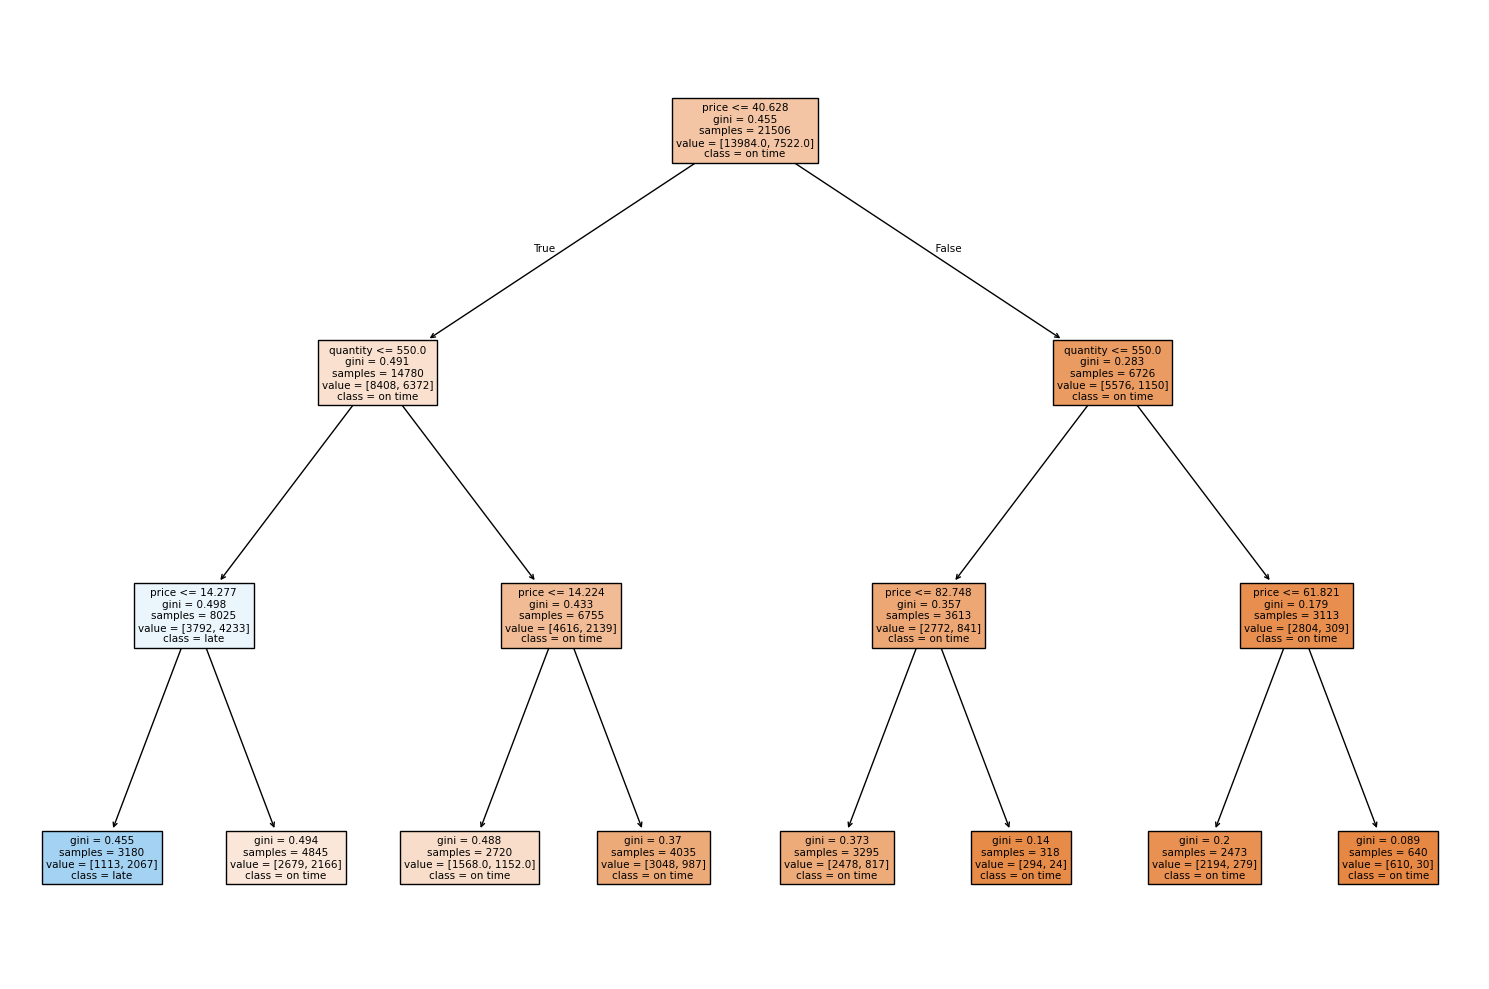

In [29]:
plt.figure(figsize=(15, 10))
plot_tree(
        tree, feature_names=features, 
        class_names=['on time', 'late'], 
        filled=True
        )
plt.tight_layout()
plt.savefig('decision_tree_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

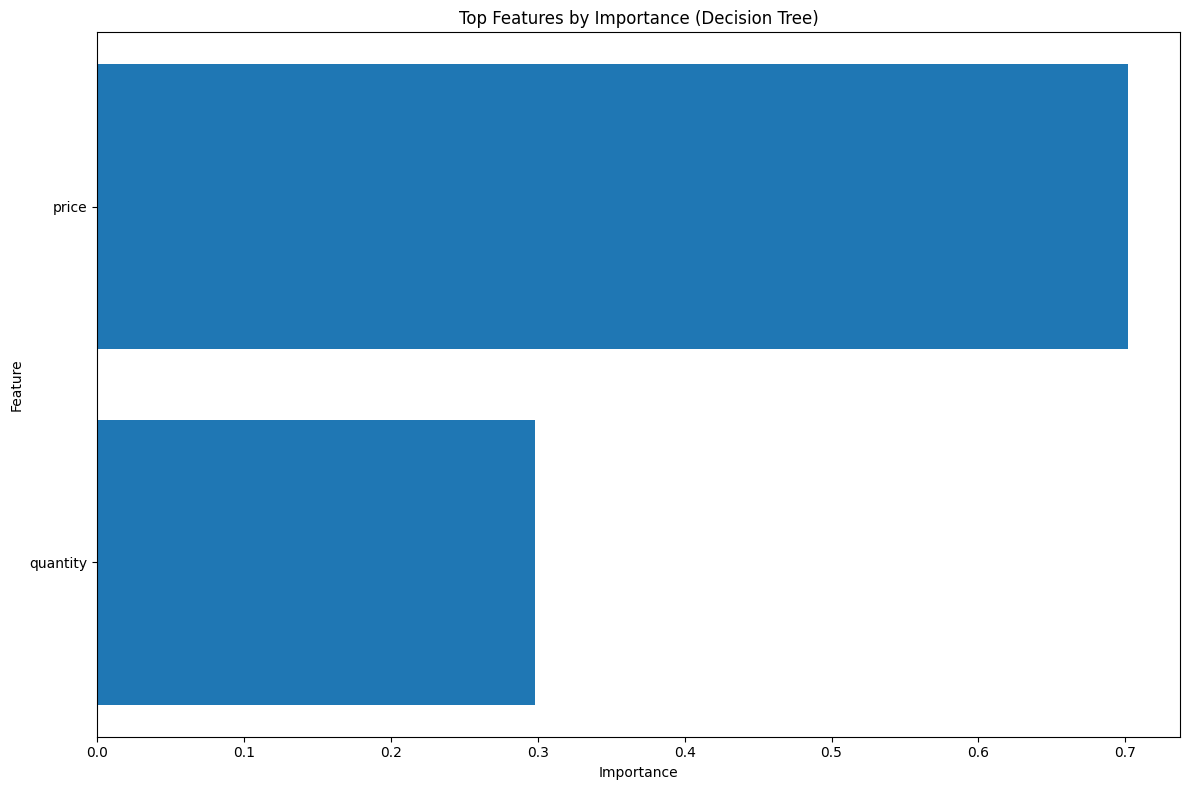

In [30]:
# Get feature importance from your decision tree model (the one with max_depth=3)
tree_importances = tree.feature_importances_
tree_indices = np.argsort(tree_importances)[::-1]  # Sort features by importance (descending)

# Create a DataFrame to store feature names and their importance
tree_importance_df = pd.DataFrame({
    'Feature': [features[i] for i in tree_indices],
    'Importance': [tree_importances[i] for i in tree_indices]
})

# Plot the top N most important features
n_features = 20  # You can adjust this number
top_tree_features = tree_importance_df.head(n_features)

plt.figure(figsize=(12, 8))
plt.barh(top_tree_features['Feature'][::-1], top_tree_features['Importance'][::-1])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top Features by Importance (Decision Tree)')
plt.tight_layout()
plt.savefig('decision_tree_feature_importance.png', dpi=300)
plt.show()

## 6. Model Evaluation

### Get Accuracy of the decision tree

In [31]:
# First calculate predictions
y_pred = tree.predict(transactions[features])
y_true = transactions['late']


get the confusion matrix

In [32]:
cm = confusion_matrix(y_true, y_pred, labels=[1, 0])

#### Transpose the confusion matrix to invert the axes (same order as in lecture notes)
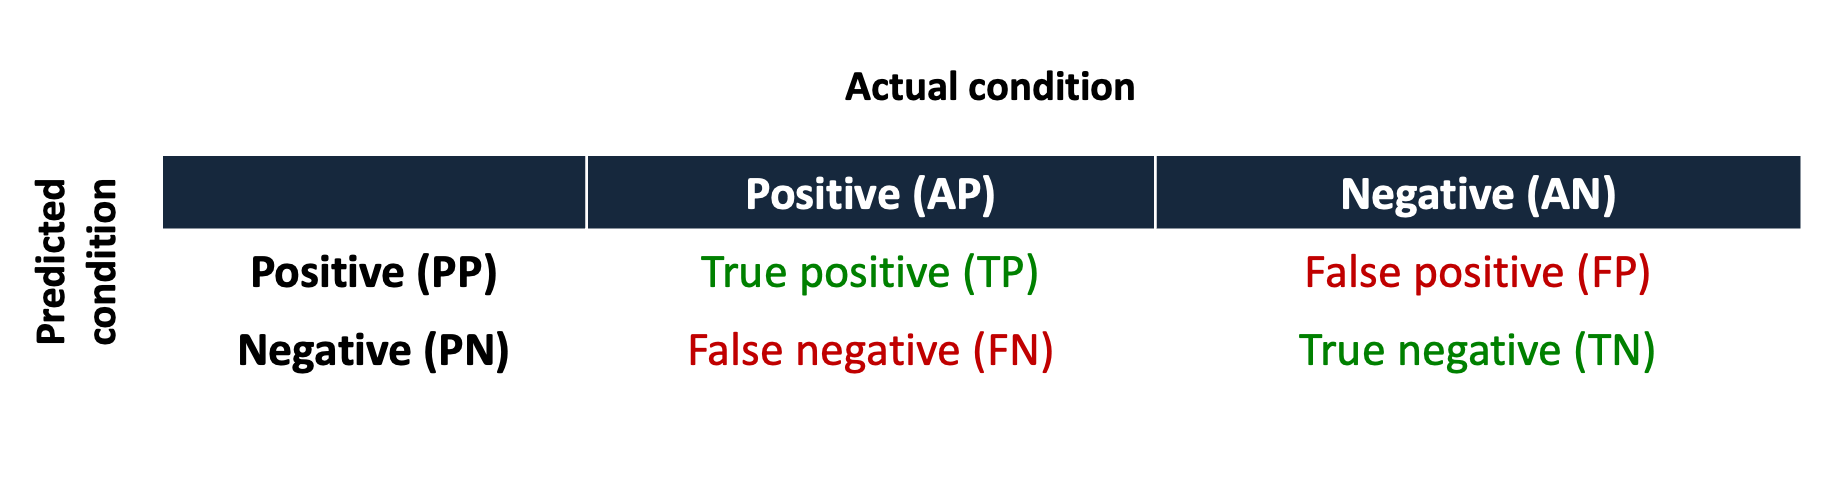



In [33]:
cm_transposed = cm.T

Display the confusion matrix

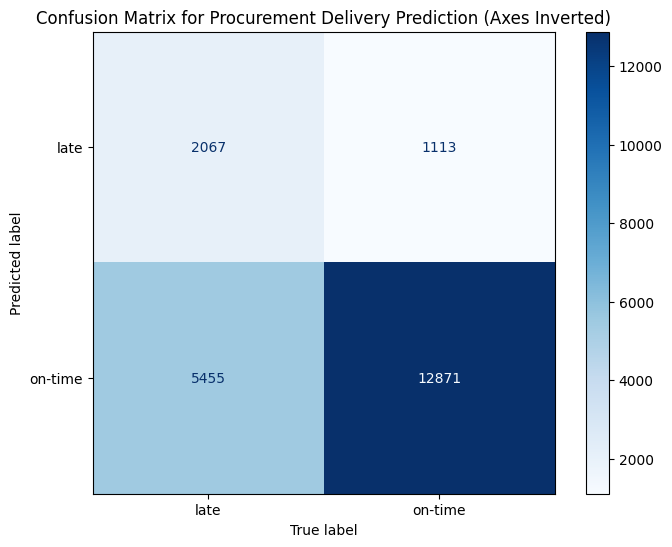

In [34]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_transposed, 
                             display_labels=['late', 'on-time'])

# Create a figure and plot
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.xlabel('True label')  # This will now be on the x-axis
plt.ylabel('Predicted label')  # This will now be on the y-axis
plt.title('Confusion Matrix for Procurement Delivery Prediction (Axes Inverted)')
plt.show()

Accuracy: What percentage of the model's predictions were correct?

In [35]:
accuracy_score(y_true=y_true, y_pred=y_pred)

0.694596856691156

Precision: Out of all the positive predictions (delivery is late), how many were actually correct?


In [36]:
precision_score(y_true=y_true, y_pred=y_pred)

0.65

Recall: Of all the actual positive instances, how many did the model correctly identify? 


In [37]:
recall_score(y_true=y_true, y_pred=y_pred)

0.27479393778250466

Calculate Specificity: Of all the actual negative instances (delivery is on time), how many did the model correctly identify?


In [38]:
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)


In [39]:
specificity

np.float64(0.27479393778250466)

Beautified Output

In [40]:
print(f"Specificity: {specificity:.2f}")

Specificity: 0.27


F-1 Score

In [41]:
f1_score(y_true=y_true, y_pred=y_pred)

0.38628293776864137

## 5. Random Forest

In [42]:
rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=random_var)

In [43]:
rf.fit(X=transactions[features], y=transactions['late'])

,n_estimators,100
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



Plot the first 3 trees in the random forest

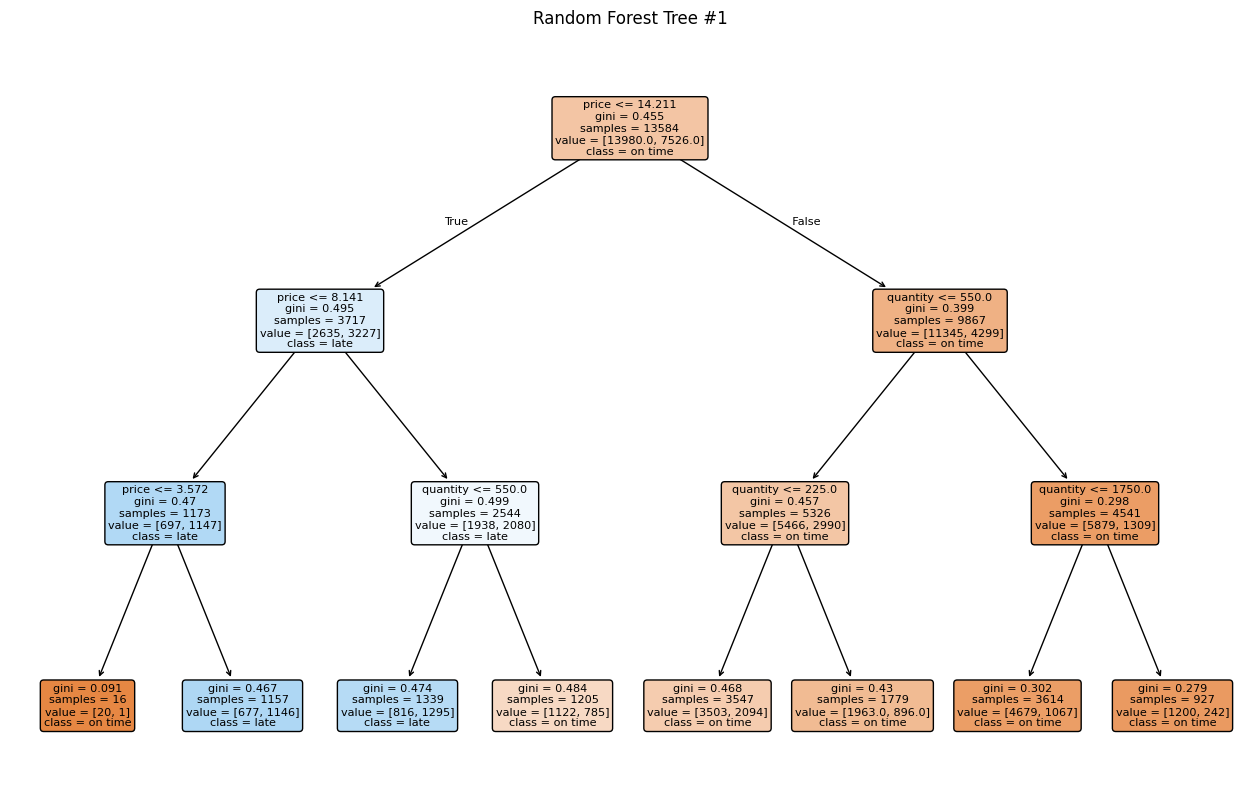

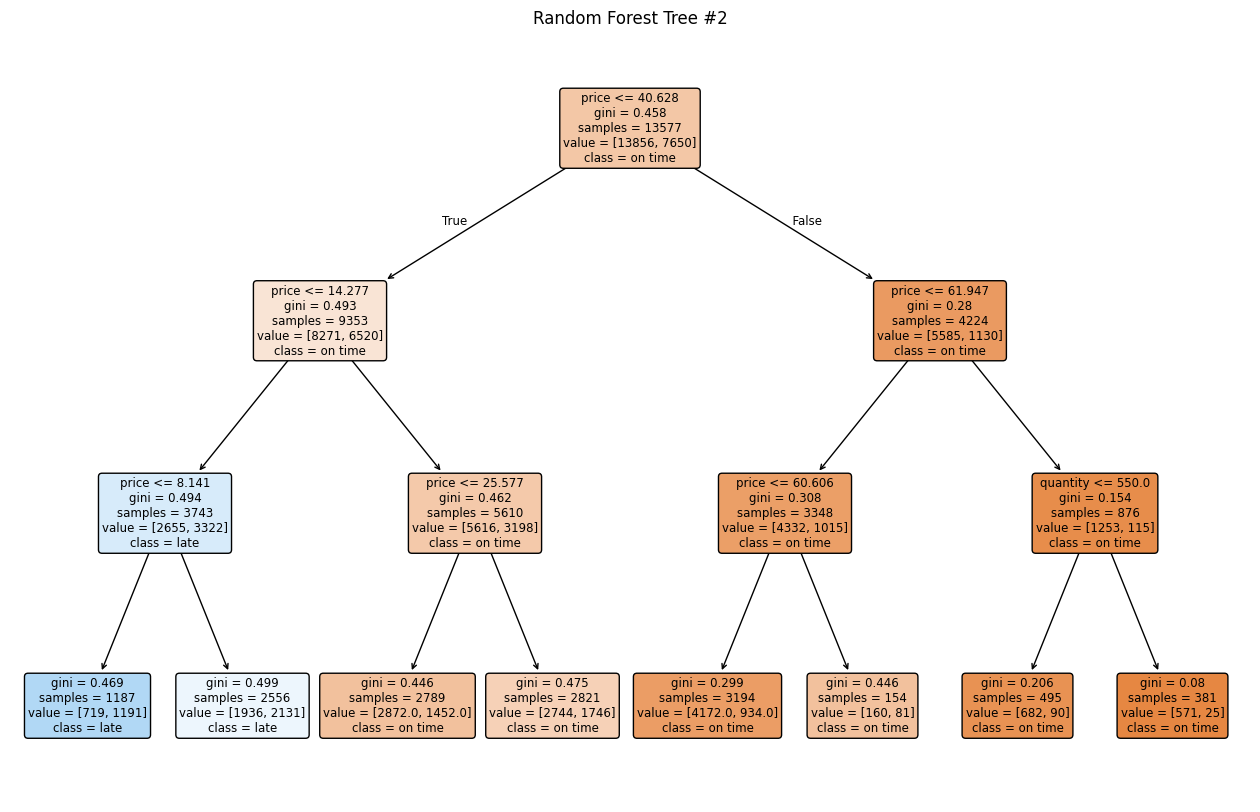

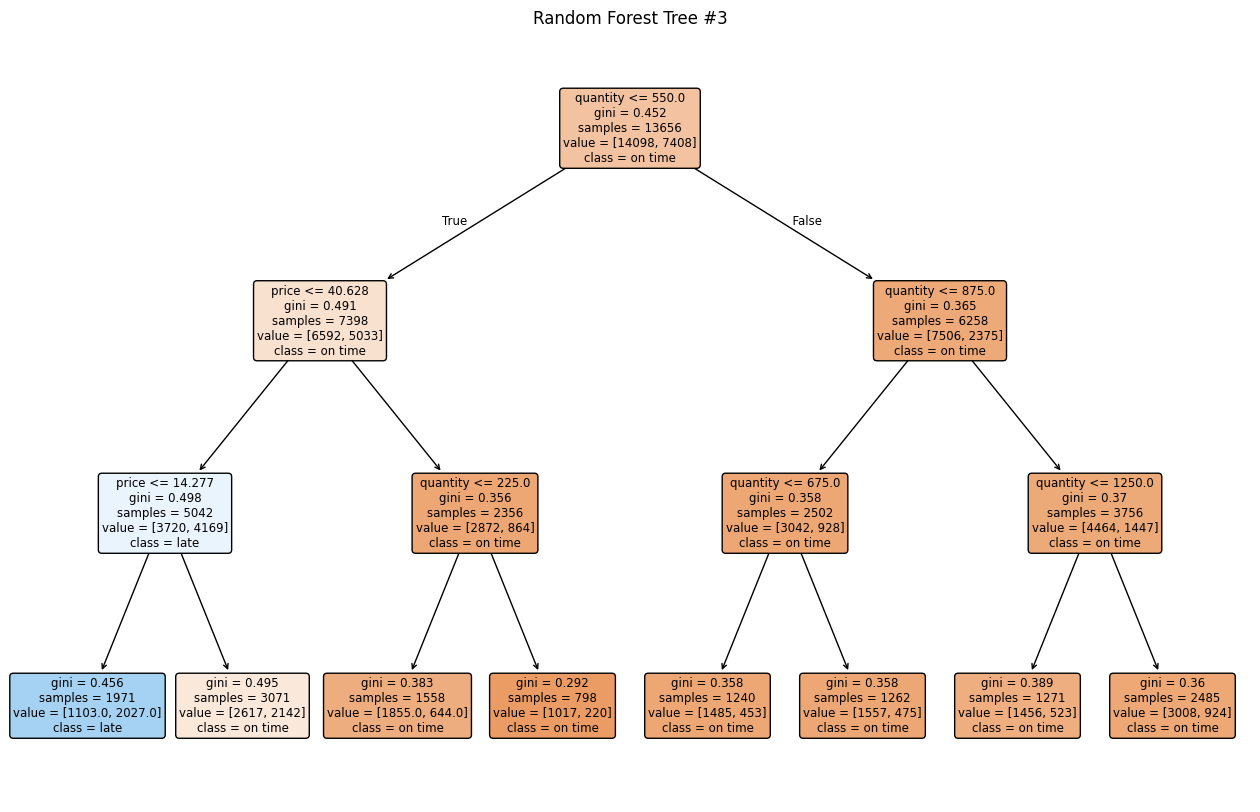

In [44]:

for i in range(3):
    plt.figure(figsize=(16, 10))
    plot_tree(
        rf.estimators_[i],
        feature_names=features,
        class_names=['on time', 'late'],
        filled=True,
        rounded=True,
        max_depth=3  # Optional: limit depth for readability
    )
    plt.title(f"Random Forest Tree #{i+1}")
    plt.show()

In [45]:
rf_pred = rf.predict(transactions[features])

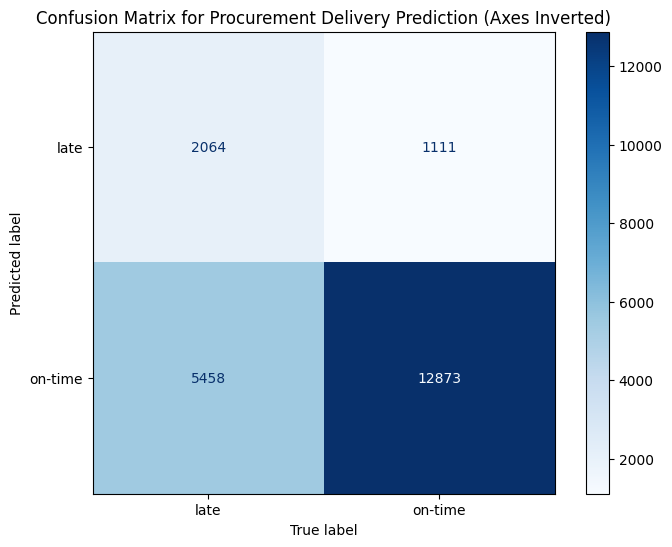

In [60]:
cm = confusion_matrix(y_true, rf_pred, labels=[1, 0])
cm_transposed = cm.T
disp = ConfusionMatrixDisplay(confusion_matrix=cm_transposed, 
                             display_labels=['late', 'on-time'])

# Create a figure and plot
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.xlabel('True label')  # This will now be on the x-axis
plt.ylabel('Predicted label')  # This will now be on the y-axis
plt.title('Confusion Matrix for Procurement Delivery Prediction (Axes Inverted)')
plt.show()

In [47]:
accuracy_score(y_true=y_true, y_pred=rf_pred)

0.6945503580396168

In [48]:
precision_score(y_true=y_true, y_pred=rf_pred)

0.6500787401574804

In [49]:
recall_score(y_true=y_true, y_pred=rf_pred)

0.27439510768412656

## 6. Gradient Boosted Trees

In [50]:
gbm = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=random_var)

In [51]:
gbm.fit(X=transactions[features], y=transactions['late'])

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [52]:
gbm_pred = gbm.predict(transactions[features])

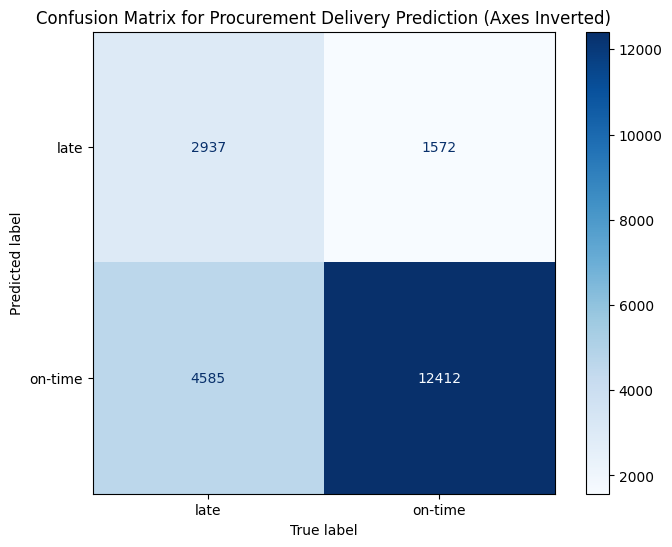

In [59]:
cm = confusion_matrix(y_true, gbm_pred, labels=[1, 0])
cm_transposed = cm.T
disp = ConfusionMatrixDisplay(confusion_matrix=cm_transposed, 
                             display_labels=['late', 'on-time'])

# Create a figure and plot
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.xlabel('True label')  # This will now be on the x-axis
plt.ylabel('Predicted label')  # This will now be on the y-axis
plt.title('Confusion Matrix for Procurement Delivery Prediction (Axes Inverted)')
plt.show()

In [54]:
accuracy_score(y_true=y_true, y_pred=gbm_pred)


0.7137078024737282

In [55]:
precision_score(y_true=y_true, y_pred=gbm_pred)

0.6513639387890885

In [56]:
recall_score(y_true=y_true, y_pred=gbm_pred)

0.39045466631215103